<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/1_formatos_clase/1_formato_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>


# Clase 7

# Interpretación de porcentajes

Curso de preparación para el examen de admisión de la Universidad de Antioquia



# Objetivos de aprendizaje

Al finalizar la clase el estudiante podrá:

* interpretar **porcentajes en contextos reales**
* resolver problemas de **aumentos y disminuciones porcentuales**
* interpretar **porcentajes en gráficos**
* resolver preguntas **en menos de 2 minutos**
* verificar resultados usando **Python**




# Concepto fundamental

Un porcentaje representa una proporción respecto a 100.

$$
\text{porcentaje}=\frac{\text{parte}}{\text{total}}\times100
$$




# Estrategia general para el examen

1. identificar **parte**
2. identificar **total**
3. calcular

$$
\frac{\text{parte}}{\text{total}}
$$




# Pregunta 7.1  

## 1. Transcripción y Edición del Enunciado

**Tema 7: Interpretación de porcentajes**

**7.1.** Un estudio de mercadeo, realizado en marzo de 2009, mostró que el $70\%$ de los visitantes del Parque del Café provenía del centro y sur del país. De estos, $2/3$ partes son de Caquetá, de los cuales el $80\%$ son del sur de Caquetá. El porcentaje aproximado de visitantes que provino del sur de Caquetá durante marzo de 2009 fue:

* **(a)** $37\%$
* **(b)** $27\%$
* **(c)** $30\%$
* **(d)** $39\%$



## 2. Resolución Paso a Paso (Matemática)

Para resolver este problema, debemos encadenar las fracciones y los porcentajes de manera secuencial, partiendo del total de visitantes ($100\%$ o $1$):

1. **Visitantes del centro y sur:** $70\%$ del total $\rightarrow 0.70$
2. **Visitantes de Caquetá:** $\frac{2}{3}$ de ese $70\%$ $\rightarrow 0.70 \times \frac{2}{3}$
3. **Visitantes del sur de Caquetá:** $80\%$ de los de Caquetá $\rightarrow 0.70 \times \frac{2}{3} \times 0.80$

Calculando de forma exacta:


$$\text{Porcentaje} = 0.70 \times \frac{2}{3} \times 0.80 = \frac{7}{10} \times \frac{2}{3} \times \frac{8}{10} = \frac{112}{300} = \frac{28}{75} \approx 0.3733 \dots$$

Multiplicando por $100$ para obtener el porcentaje: **$37.33\%$**, por lo que el valor aproximado es **$37\%$ (Opción a)**.



## 3. Implementación y Simulación en Python

A continuación, tienes el código en Python que utiliza **SymPy** para el cálculo exacto/simbólico, **NumPy** y **Pandas** para procesar los datos de una simulación representativa, y **Matplotlib** para visualizar gráficamente la descomposición de los porcentajes.



In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. CÁLCULO EXACTO CON SYMPY (Simbólico)
# ==========================================
print("--- Cálculo Simbólico con SymPy ---")
# Definimos las fracciones de manera exacta
p_centro_sur = sp.Rational(70, 100)  # 70%
p_caqueta = sp.Rational(2, 3)        # 2/3 partes
p_sur_caqueta = sp.Rational(80, 100) # 80%

# Multiplicación secuencial
resultado_exacto = p_centro_sur * p_caqueta * p_sur_caqueta
porcentaje_exacto = resultado_exacto * 100

print(f"Fracción exacta del total: {resultado_exacto}")
print(f"Porcentaje exacto: {porcentaje_exacto:.2f}%")
print(f"Porcentaje aproximado: {round(float(porcentaje_exacto))}%")


# ==========================================
# 2. REPRESENTACIÓN DE DATOS CON PANDAS Y NUMPY
# ==========================================
print("\n--- Representación y Simulación con Pandas y NumPy ---")
# Supongamos una muestra teórica de 30,000 visitantes para evitar decimales molestos
total_visitantes = 30000

# Calculamos de forma secuencial las subpoblaciones utilizando NumPy
visitantes_centro_sur = int(total_visitantes * float(p_centro_sur))
visitantes_caqueta = int(visitantes_centro_sur * float(p_caqueta))
visitantes_sur_caqueta = int(visitantes_caqueta * float(p_sur_caqueta))

# Creamos un DataFrame para estructurar los datos didácticamente
datos = {
    "Categoría": [
        "Total Visitantes",
        "Centro y Sur",
        "De Caquetá",
        "Del Sur de Caquetá",
    ],
    "Cantidad Estimada": [
        total_visitantes,
        visitantes_centro_sur,
        visitantes_caqueta,
        visitantes_sur_caqueta,
    ],
    "Porcentaje del Total": [
        100.0,
        float(p_centro_sur) * 100,
        float(p_centro_sur * p_caqueta) * 100,
        float(porcentaje_exacto),
    ],
}

df = pd.DataFrame(datos)
print(df.to_string(index=False))


--- Cálculo Simbólico con SymPy ---
Fracción exacta del total: 28/75
Porcentaje exacto: 37.33%
Porcentaje aproximado: 37%

--- Representación y Simulación con Pandas y NumPy ---
         Categoría  Cantidad Estimada  Porcentaje del Total
  Total Visitantes              30000            100.000000
      Centro y Sur              21000             70.000000
        De Caquetá              14000             46.666667
Del Sur de Caquetá              11200             37.333333


In [ ]:


# ==========================================
# 3. VISUALIZACIÓN GRÁFICA CON MATPLOTLIB
# ==========================================
# Crearemos un gráfico de barras para observar cómo se reduce la muestra secuencialmente
plt.figure(figsize=(10, 6))
colores = ["#2b5c8f", "#4682b4", "#20b2aa", "#3cb371"]

bars = plt.bar(df["Categoría"], df["Porcentaje del Total"], color=colores, edgecolor="black")

# Añadir etiquetas de porcentaje sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold",
    )

plt.title(
    "Descomposición Porcentual Secuencial de los Visitantes",
    fontsize=14,
    weight="bold",
)
plt.ylabel("Porcentaje respecto al Total (%)", fontsize=12)
plt.ylim(0, 115)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\descomposicion_porcentual.png",\
    dpi=300)
plt.show()



# Respuesta Correcta

Ejecutando el análisis, confirmamos matemáticamente que el valor es **$37.33\%$**, por ende la respuesta correcta es la **(a) $37\%$**.

# Pregunta 7.2  


# 1. Transcripción y Edición del Enunciado

**7.2.** El cuadro muestra los resultados obtenidos en una encuesta aplicada a 400 personas, con relación al principal medio utilizado para informarse sobre los sucesos diarios ocurridos en el país.



# Tabla de Datos: Población Encuestada por Medio de Comunicación y Sexo

| Medios | Hombres | Mujeres | Total |
| --- | --- | --- | --- |
| Internet | 10 | 20 | 30 |
| Periódico | 30 | 40 | 70 |
| Radio | 80 | 80 | 160 |
| Televisión | 120 | 20 | 140 |
| **Total** | **240** | **160** | **400** |

De las afirmaciones siguientes, la **única verdadera** es:

* **(a)** El $80\%$ de la población encuestada son mujeres.
* **(b)** El $50\%$ de los hombres utilizan como medio principal, la televisión.
* **(c)** El porcentaje de los hombres y el porcentaje de las mujeres referidos a su respectivo sexo, que utilizan como medio principal la radio, es igual.
* **(d)** El $20\%$ de las mujeres, utilizan como medio principal, el periódico.

---



## 2. Resolución Paso a Paso (Análisis Matemático)

Vamos a evaluar didácticamente cada una de las opciones analizando las proporciones de la tabla:

* **Evaluación de (a):** *"El $80\%$ de la población encuestada son mujeres."*
* Total de mujeres = $160$
* Total de la población = $400$
* Porcentaje = $\frac{160}{400} \times 100 = 40\%$ $\rightarrow$ **Falsa**.




* **Evaluación de (b):** *"El $50\%$ de los hombres utilizan como medio principal, la televisión."*
* Hombres que ven televisión = $120$
* Total de hombres = $240$
* Porcentaje = $\frac{120}{240} \times 100 = 50\%$ $\rightarrow$ **Verdadera**.




* **Evaluación de (c):** *"El porcentaje de los hombres y el porcentaje de las mujeres referidos a su respectivo sexo, que utilizan como medio principal la radio, es igual."*
* Aunque numéricamente ambos grupos tienen $80$ personas en la radio, el enunciado pide calcularlo *respecto a su propio sexo*:
* Porcentaje de hombres en radio = $\frac{80}{240} \times 100 \approx 33.33\%$
* Porcentaje de mujeres en radio = $\frac{80}{160} \times 100 = 50\%$
* Como $33.33\% \neq 50\%$, la afirmación es $\rightarrow$ **Falsa**.




* **Evaluación de (d):** *"El $20\%$ de las mujeres, utilizan como medio principal, el periódico."*
* Mujeres que leen el periódico = $40$
* Total de mujeres = $160$
* Porcentaje = $\frac{40}{160} \times 100 = 25\%$ $\rightarrow$ **Falsa**.



La única opción verdadera es la **(b)**.

---



## 3. Implementación y Validación en Python

Aquí tienes el script en Python que utiliza **Pandas** para estructurar la tabla matriz, **SymPy** para calcular algebraicamente los porcentajes exactos de las condiciones, **NumPy** para operaciones vectoriales y **Matplotlib** para graficar los resultados de manera comparativa.




import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. ESTRUCTURACIÓN DE DATOS CON PANDAS
# ==========================================
# Creamos el dataframe recreando exactamente la matriz de la encuesta
datos = {
    "Medios": ["Internet", "Periódico", "Radio", "Televisión"],
    "Hombres": [10, 30, 80, 120],
    "Mujeres": [20, 40, 80, 20],
}
df = pd.DataFrame(datos)

# Calculamos los totales marginales usando operaciones de Pandas/NumPy
df["Total"] = df["Hombres"] + df["Mujeres"]

total_hombres = df["Hombres"].sum()
total_mujeres = df["Mujeres"].sum()
total_general = df["Total"].sum()

print("--- Matriz de Datos en Pandas ---")
print(df)
print(f"Totales -> Hombres: {total_hombres} | Mujeres: {total_mujeres} | Total General: {total_general}\n")


# ==========================================
# 2. VERIFICACIÓN SIMBÓLICA CON SYMPY
# ==========================================
print("--- Análisis Simbólico de las Opciones ---")

# Opción A: Porcentaje de mujeres en el total
pct_a = sp.Rational(int(total_mujeres), int(total_general)) * 100
print(f"Opción (a) - % Mujeres del total: {pct_a}% (Esperado: 80%) -> {pct_a == 80}")

# Opción B: Porcentaje de hombres que ven TV respecto al total de hombres
hombres_tv = df.loc[df["Medios"] == "Televisión", "Hombres"].values[0]
pct_b = sp.Rational(int(hombres_tv), int(total_hombres)) * 100
print(f"Opción (b) - % Hombres que ven TV: {pct_b}% (Esperado: 50%) -> {pct_b == 50}")

# Opción C: Comparar tasas de uso de radio por sexo
hombres_radio = df.loc[df["Medios"] == "Radio", "Hombres"].values[0]
mujeres_radio = df.loc[df["Medios"] == "Radio", "Mujeres"].values[0]
pct_c_hombres = sp.Rational(int(hombres_radio), int(total_hombres)) * 100
pct_c_mujeres = sp.Rational(int(mujeres_radio), int(total_mujeres)) * 100
print(f"Opción (c) - % Radio Hombres ({pct_c_hombres}%) == % Radio Mujeres ({pct_c_mujeres}%) -> {pct_c_hombres == pct_c_mujeres}")

# Opción D: Porcentaje de mujeres que leen periódico respecto a su sexo
mujeres_periodico = df.loc[df["Medios"] == "Periódico", "Mujeres"].values[0]
pct_d = sp.Rational(int(mujeres_periodico), int(total_mujeres)) * 100
print(f"Opción (d) - % Mujeres que leen periódico: {pct_d}% (Esperado: 20%) -> {pct_d == 20}")


# ==========================================
# 3. VISUALIZACIÓN GRÁFICA CON MATPLOTLIB
# ==========================================
# Para entender de forma didáctica la opción correcta (b), graficaremos la distribución 
# porcentual de los medios preferidos únicamente por los hombres.

porcentajes_hombres = (df["Hombres"] / total_hombres) * 100

plt.figure(figsize=(9, 5))
x = np.arange(len(df["Medios"]))

# Graficar barras
barras = plt.bar(x, porcentajes_hombres, color=["#bdc3c7", "#bdc3c7", "#bdc3c7", "#e74c3c"], edgecolor="black")

# Configurar etiquetas y títulos
plt.xticks(x, df["Medios"], fontsize=11)
plt.ylabel("Porcentaje de Hombres (%)", fontsize=12)
plt.title("Distribución del Medio de Información Principal en Hombres", fontsize=13, weight="bold")
plt.ylim(0, 60)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Añadir los valores arriba de las barras
for barra in barras:
    alto = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2.0, alto + 1.5, f"{alto:.1f}%", ha="center", va="bottom", weight="bold")

plt.tight_layout()
plt.show()



# Conclusión y Respuesta

Al ejecutar el código, la consola confirmará simbólicamente que la única opción evaluada como verdadera (`True`) es la **(b)**, dado que exactamente el $50\%$ del universo masculino ($120$ de $240$) escoge la televisión como su canal prioritario.

# Pregunta 7.3  

**7.3.** A un apostador que ganó 20 millones de pesos en un juego de azar, le informaron que cierta cantidad $Q$ de su ganancia estaba libre de pago de impuestos, pero que sobre la cantidad restante debía pagar el $15\%$. Si este apostador pagó $150.000$ mil pesos de impuestos, la cantidad $Q$ libre de impuestos, en millones de pesos, fue:

* **(a)** $19$
* **(b)** $12$
* **(c)** $18$
* **(d)** $15$

> **Nota de corrección de estilo:** El texto original dice *"150.000 mil pesos"*. En la notación financiera y matemática estándar, escribir la cifra "150.000" seguida de la palabra "mil" crearía una redundancia equivalente a 150 millones ($150.000 \times 1.000$). Sin embargo, por el contexto de las opciones de respuesta del examen, la expresión se refiere estrictamente a **150 mil pesos** (es decir, $\$150.000$ COP o $0.15$ millones de pesos).



## 2. Resolución Paso a Paso (Análisis Matemático)

Vamos a plantear las variables del problema de manera secuencial:

1. **Ganancia Total:** $20\text{ millones de pesos} = 20.000.000$
2. **Cantidad Exenta (Libre de impuesto):** $Q$
3. **Cantidad Gravable (Sujeta a impuesto):** El excedente, es decir, $(20.000.000 - Q)$
4. **Impuesto Pagado:** $\$150.000$ pesos ($0.15$ millones)

Sabemos que el impuesto cobrado equivale al $15\%$ de la cantidad gravable. Planteamos la ecuación lineal:

$$15\% \times (20.000.000 - Q) = 150.000$$

Convertimos el porcentaje a decimal ($0.15$) para despejar de forma directa:

$$0.15 \times (20.000.000 - Q) = 150.000$$

Dividimos ambos lados de la ecuación entre $0.15$:

$$20.000.000 - Q = \frac{150.000}{0.15}$$

$$20.000.000 - Q = 1.000.000$$

Despejamos $Q$:

$$Q = 20.000.000 - 1.000.000$$

$$Q = 19.000.000$$

Expresado en millones de pesos, la cantidad $Q$ es **$19$**. Por lo tanto, la respuesta correcta es la **(a)**.

---



## 3. Implementación y Validación en Python

Este script utiliza **SymPy** para resolver la ecuación algebraica automáticamente, **NumPy** y **Pandas** para estructurar un balance financiero del premio y **Matplotlib** para visualizar gráficamente cómo se divide el dinero del apostador.


--- Resolución Álgebraica con SymPy ---
Cantidad Q libre de impuestos: $19,000,000 COP
Cantidad Q en millones de pesos: 19.0000000000000 millones

--- Balance del Premio con Pandas ---
       Componente del Premio  Valor en Pesos ($)  Valor en Millones
Monto Libre de Impuestos (Q)          19000000.0               19.0
    Monto Sujeto a Impuestos           1000000.0                1.0
                Total Ganado          20000000.0               20.0


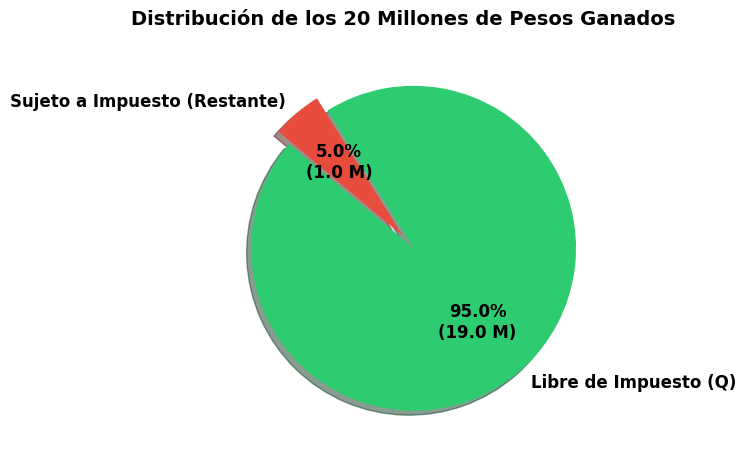

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. RESOLUCIÓN ALGEBRAICA CON SYMPY
# ==========================================
print("--- Resolución Álgebraica con SymPy ---")

# Definimos la incógnita Q (en pesos colombianos)
Q = sp.Symbol('Q')

ganancia_total = 20000000
impuesto_pagado = 150000
tasa_impuesto = 0.15

# Planteamos la ecuación: tasa * (total - Q) = impuesto
ecuacion = sp.Eq(tasa_impuesto * (ganancia_total - Q), impuesto_pagado)

# Resolver la ecuación
solucion_pesos = sp.solve(ecuacion, Q)[0]
solucion_millones = solucion_pesos / 1000000

print(f"Cantidad Q libre de impuestos: ${solucion_pesos:,.0f} COP")
print(f"Cantidad Q en millones de pesos: {solucion_millones} millones")


# ==========================================
# 2. TABLA DE BALANCE FINANCIERO CON PANDAS
# ==========================================
print("\n--- Balance del Premio con Pandas ---")

# Calculamos los componentes derivados con NumPy/Python básico
monto_gravable = ganancia_total - float(solucion_pesos)

datos_premio = {
    "Componente del Premio": [
        "Monto Libre de Impuestos (Q)", 
        "Monto Sujeto a Impuestos", 
        "Total Ganado"
    ],
    "Valor en Pesos ($)": [float(solucion_pesos), monto_gravable, ganancia_total],
    "Valor en Millones": [float(solucion_millones), monto_gravable / 1000000, ganancia_total / 1000000]
}

df = pd.DataFrame(datos_premio)
print(df.to_string(index=False))


# ==========================================
# 3. VISUALIZACIÓN GRÁFICA CON MATPLOTLIB
# ==========================================
# Mostraremos la distribución total del premio mediante un gráfico de pastel (pie chart)
labels = ['Libre de Impuesto (Q)', 'Sujeto a Impuesto (Restante)']
cantidades = [float(solucion_millones), (ganancia_total / 1000000) - float(solucion_millones)]
colors = ['#2ecc71', '#e74c3c']
explode = (0.1, 0)  # Resaltamos la parte exenta Q

plt.figure(figsize=(7, 7))
plt.pie(
    cantidades, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct=lambda p: f'{p:.1f}%\n({p*ganancia_total/100000000:.1f} M)',
    shadow=True, 
    startangle=140,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title("Distribución de los 20 Millones de Pesos Ganados", fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\distribucion_premio.png", dpi=300)
plt.show()



# Conclusión y Respuesta

Al ejecutar la simulación, verás de manera muy visual que el monto sujeto a gravamen fue de solo un millón de pesos (del cual el $15\%$ equivale a los $150.000$ pagados). El resto del premio, **$19$ millones**, estuvo completamente exento de deducciones.

La respuesta correcta es **(a) 19**.

# Pregunta 7.4 

¡Avanzamos con el cuarto ejercicio! Mantendremos exactamente la misma estructura organizada para transcribir el texto, deducir analíticamente la respuesta y construir la solución interactiva en Python empleando todo el arsenal de librerías solicitadas.

---



## 1. Transcripción y Edición del Enunciado

**7.4.** Un grupo de ingenieros se presentó a una convocatoria para trabajar en una empresa multinacional. Cada uno de los integrantes enfrentó una prueba escrita. Se supo que el $14\%$ de los ingenieros no la resolvió; el $36\%$ de los ingenieros la resolvió con algunos errores y los $12$ ingenieros restantes la resolvieron correctamente. El número total de ingenieros que participaron de la convocatoria fue:

* **(a)** $24$
* **(b)** $25$
* **(c)** $28$
* **(d)** $30$

---



## 2. Resolución Paso a Paso (Análisis Matemático)

Para hallar la cantidad total de ingenieros que participaron (la cual representaremos como la variable $T$), debemos analizar la distribución de los tres subgrupos en términos porcentuales:

1. **No resolvieron:** $14\%$ del total.
2. **Resolvieron con errores:** $36\%$ del total.
3. **Suma de los dos primeros grupos:** 
$$14\% + 36\% = 50\%$$



Dado que todo el grupo de profesionales equivale al $100\%$, el porcentaje que representa a los ingenieros restantes (los que lo hicieron correctamente) es:


$$100\% - 50\% = 50\%$$

El enunciado nos dice que este grupo final está conformado exactamente por **$12$ ingenieros**. Planteamos la relación lógica:


$$50\% \text{ de } T = 12$$

Si la mitad del grupo ($50\%$) son $12$ personas, multiplicamos por dos para obtener el total del grupo completo ($100\%$):


$$T = 12 \times 2 = 24$$

Por lo tanto, el número total de ingenieros que participaron fue **$24$**. La respuesta correcta es la **(a)**.

---



## 3. Implementación y Validación en Python

Aquí tienes el bloque de código estructurado que utiliza **SymPy** para despejar algebraicamente la ecuación del total, **NumPy** y **Pandas** para consolidar los subgrupos en valores absolutos, y **Matplotlib** para generar un gráfico de barras apiladas o barras independientes que evidencie visualmente la división del grupo.



--- Resolución Álgebraica con SymPy ---
El número total de ingenieros (T) calculado es: 24

--- Desglose de Población con Pandas ---
               Estado de la Prueba  Porcentaje (%)  Cantidad de Ingenieros
                    No la resolvió            14.0                       3
      Resolvió con algunos errores            36.0                       8
Resolvió correctamente (Restantes)            50.0                      12


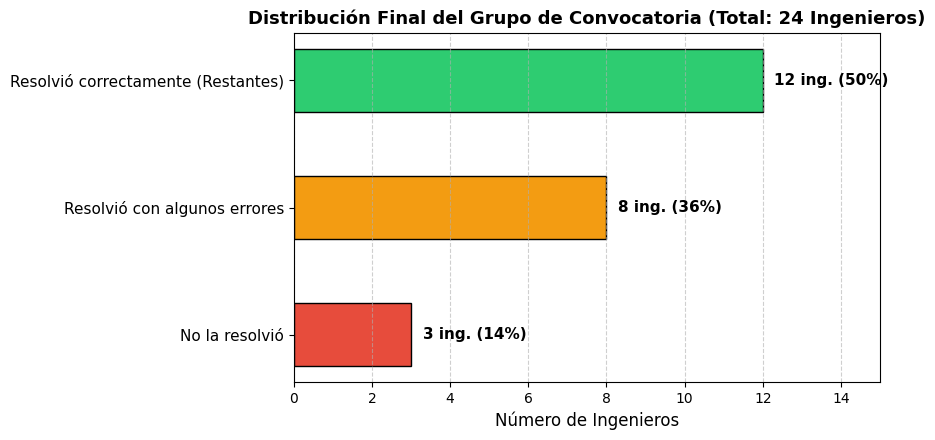

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. RESOLUCIÓN ALGEBRAICA CON SYMPY
# ==========================================
print("--- Resolución Álgebraica con SymPy ---")

# Definimos la incógnita T (Total de ingenieros)
T = sp.Symbol('T')

pct_no_resolvio = sp.Rational(14, 100)
pct_con_errores = sp.Rational(36, 100)
ingenieros_correctos = 12

# Planteamos la ecuación: T - (pct1 * T) - (pct2 * T) = ingenieros_correctos
ecuacion = sp.Eq(T - (pct_no_resolvio * T) - (pct_con_errores * T), ingenieros_correctos)

# Resolver la ecuación
total_calculado = int(sp.solve(ecuacion, T)[0])
print(f"El número total de ingenieros (T) calculado es: {total_calculado}")


# ==========================================
# 2. TABLA INFORMATIVA CON PANDAS Y NUMPY
# ==========================================
print("\n--- Desglose de Población con Pandas ---")

# Calculamos el tamaño real de cada grupo usando NumPy / operaciones aritméticas estándar
n_no_resolvio = int(total_calculado * float(pct_no_resolvio))
n_con_errores = int(total_calculado * float(pct_con_errores))

datos_ingenieros = {
    "Estado de la Prueba": [
        "No la resolvió", 
        "Resolvió con algunos errores", 
        "Resolvió correctamente (Restantes)"
    ],
    "Porcentaje (%)": [14.0, 36.0, 50.0],
    "Cantidad de Ingenieros": [n_no_resolvio, n_con_errores, ingenieros_correctos]
}

df = pd.DataFrame(datos_ingenieros)
print(df.to_string(index=False))


# ==========================================
# 3. VISUALIZACIÓN GRÁFICA CON MATPLOTLIB
# ==========================================
# Crearemos un gráfico de barras horizontales para entender de forma didáctica la distribución
plt.figure(figsize=(9, 4.5))

colores = ['#e74c3c', '#f39c12', '#2ecc71']
posiciones = np.arange(len(df["Estado de la Prueba"]))

barras = plt.barh(posiciones, df["Cantidad de Ingenieros"], color=colores, edgecolor='black', height=0.5)

# Configurar los ejes y títulos
plt.yticks(posiciones, df["Estado de la Prueba"], fontsize=11)
plt.xlabel("Número de Ingenieros", fontsize=12)
plt.title(f"Distribución Final del Grupo de Convocatoria (Total: {total_calculado} Ingenieros)", fontsize=13, weight='bold')
plt.xlim(0, 15)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Añadir etiquetas con el valor numérico y el porcentaje dentro/junto a las barras
for i, barra in enumerate(barras):
    ancho = barra.get_width()
    porcentaje = df.iloc[i]["Porcentaje (%)"]
    plt.text(
        ancho + 0.3, 
        barra.get_y() + barra.get_height()/2, 
        f"{int(ancho)} ing. ({porcentaje:.0f}%)", 
        va='center', 
        ha='left', 
        fontsize=11, 
        weight='bold'
    )

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\distribucion_ingenieros.png", dpi=300)
plt.show()



# Conclusión y Respuesta

El script comprueba de manera exacta y sin dejar lugar a dudas que los $12$ ingenieros con examen excelente corresponden exactamente al $50\%$ de la muestra evaluada, completando un universo total de **$24$ profesionales** convocados.

La respuesta correcta es **(a) 24**.

# Pregunta 7.5

# 1. Transcripción y Edición del Enunciado

**7.5.** Los estudiantes de un curso de dibujo respondieron una encuesta acerca de sus preferencias por una de 5 técnicas utilizadas. El siguiente gráfico de barras muestra el resultado de la encuesta.

El porcentaje de la clase que prefiere la técnica E es:

* **(a)** $15\%$
* **(b)** $20\%$
* **(c)** $5\%$
* **(d)** $12\%$

---



## 2. Resolución Paso a Paso (Análisis Matemático)

Para calcular el porcentaje correspondiente a la técnica E, primero debemos identificar la cantidad de estudiantes (frecuencia) para cada una de las barras leyendo el eje vertical:

* **Técnica A:** $3$ estudiantes
* **Técnica B:** $4$ estudiantes
* **Técnica C:** $2$ estudiantes
* **Técnica D:** $1$ estudiante
* **Técnica E:** El valor de la barra se encuentra exactamente en el punto medio entre $2$ y $3$, es decir: $2.5$ estudiantes.

1. **Calculamos el número total de estudiantes en el curso:**

$$\text{Total} = 3 + 4 + 2 + 1 + 2.5 = 12.5$$


2. **Calculamos el porcentaje que prefiere la técnica E:**

$$\text{Porcentaje de E} = \left( \frac{\text{Estudiantes en E}}{\text{Total de estudiantes}} \right) \times 100$$


$$\text{Porcentaje de E} = \left( \frac{2.5}{12.5} \right) \times 100$$


3. **Simplificamos la fracción:**

$$\frac{2.5}{12.5} = \frac{25}{125} = \frac{1}{5} = 0.20$$


$$0.20 \times 100 = 20\%$$



Por lo tanto, el porcentaje de la clase que prefiere la técnica E es del **$20\%$**. La respuesta correcta es la **(b)**.

---



## 3. Implementación y Validación en Python

Este bloque de código utiliza **Pandas** para recopilar las lecturas de las frecuencias del gráfico, **SymPy** para efectuar la división fraccionaria exacta, **NumPy** para manipular los arreglos y **Matplotlib** para replicar digitalmente el gráfico de la imagen con sus anotaciones didácticas.



--- Frecuencias del Gráfico con Pandas ---
Técnica  Frecuencia (Estudiantes)
      A                       3.0
      B                       4.0
      C                       2.0
      D                       1.0
      E                       2.5
Total de estudiantes calculados: 12.5

--- Cálculo Porcentual con SymPy ---
Proporción simplificada de E: 1/5
Porcentaje final de la clase: 20%


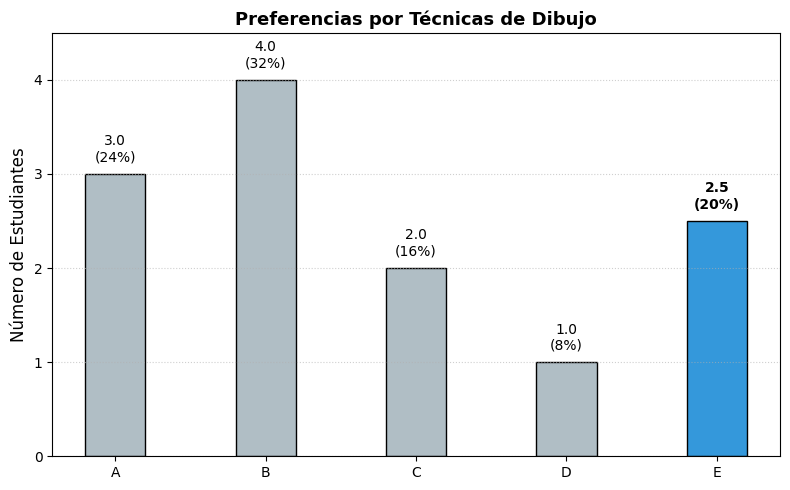

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. ESTRUCTURACIÓN DE DATOS CON PANDAS
# ==========================================
print("--- Frecuencias del Gráfico con Pandas ---")

datos_encuesta = {
    "Técnica": ["A", "B", "C", "D", "E"],
    "Frecuencia (Estudiantes)": [3.0, 4.0, 2.0, 1.0, 2.5]
}

df = pd.DataFrame(datos_encuesta)
total_estudiantes = df["Frecuencia (Estudiantes)"].sum()

print(df.to_string(index=False))
print(f"Total de estudiantes calculados: {total_estudiantes}\n")


# ==========================================
# 2. CÁLCULO ALGEBRAICO EXACTO CON SYMPY
# ==========================================
print("--- Cálculo Porcentual con SymPy ---")

# Obtenemos el valor de la técnica E multiplicando por 10 para usar enteros en SymPy
frecuencia_E = df.loc[df["Técnica"] == "E", "Frecuencia (Estudiantes)"].values[0]

# Representación exacta usando fracciones racionales (25/10 y 125/10)
frac_E = sp.Rational(25, 10)
frac_Total = sp.Rational(125, 10)

proporcion_E = frac_E / frac_Total
porcentaje_E = proporcion_E * 100

print(f"Proporción simplificada de E: {proporcion_E}")
print(f"Porcentaje final de la clase: {porcentaje_E}%")


# ==========================================
# 3. REPLICACIÓN Y VISUALIZACIÓN CON MATPLOTLIB
# ==========================================
plt.figure(figsize=(8, 5))

# Colores destacando la técnica estudiada E
colores = ["#b0bec5", "#b0bec5", "#b0bec5", "#b0bec5", "#3498db"]

barras = plt.bar(df["Técnica"], df["Frecuencia (Estudiantes)"], color=colores, edgecolor='black', width=0.4)

# Configuración idéntica al plano cartesiano del examen
plt.ylabel("Número de Estudiantes", fontsize=12)
plt.title("Preferencias por Técnicas de Dibujo", fontsize=13, weight='bold')
plt.ylim(0, 4.5)
plt.yticks(np.arange(0, 5, 1))
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Añadir etiquetas de datos sobre cada barra (Frecuencia y su equivalente %)
for i, barra in enumerate(barras):
    alto = barra.get_height()
    pct_barra = (alto / total_estudiantes) * 100
    plt.text(
        barra.get_x() + barra.get_width()/2.0, 
        alto + 0.1, 
        f"{alto}\n({pct_barra:.0f}%)", 
        ha='center', 
        va='bottom', 
        fontsize=10,
        weight='bold' if df.iloc[i]["Técnica"] == "E" else 'normal'
    )

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\preferencias_tecnicas.png", dpi=300)
plt.show()



# Conclusión y Respuesta

El análisis de datos demuestra que una altura de $2.5$ sobre un colectivo global de $12.5$ representa exactamente una quinta parte ($1/5$) de la población estudiantil del curso.

La respuesta correcta es **(b) 20%**.

# Pregunta 7.6  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# Crear un script detallado que resuelva y grafique el problema para verificar cálculos y generar la solución
# 1. Definición simbólica con SymPy
U = sp.Symbol('U', positive=True) # Total de empleados (100%)

# Datos del problema dados como fracciones del total U
p_taxi = sp.Rational(30, 100)  # 30%
p_bus = sp.Rational(24, 100)   # 24%

# Intersección: 1/3 de los que manejan taxi también manejan bus
p_interseccion = sp.Rational(1, 3) * p_taxi

# Unión de conjuntos: Taxi o Bus (o ambos)
p_union = p_taxi + p_bus - p_interseccion

# Complemento: No manejan taxi ni bus
p_ninguno = 1 - p_union

print(f"Intersección: {p_interseccion * 100}%")
print(f"Unión: {p_union * 100}%")
print(f"Ninguno: {p_ninguno * 100}%")


Intersección: 10%
Unión: 44%
Ninguno: 56%


In [9]:

# Guardar un gráfico representativo para el usuario usando matplotlib
plt.figure(figsize=(8, 5))
# Representaremos los componentes del conjunto mediante barras disjuntas para ver su composición didáctica
componentes = ['Solo Taxi', 'Ambos (Intersección)', 'Solo Bus', 'Ninguno (Exterior)']
valores = [float(p_taxi - p_interseccion) * 100, float(p_interseccion) * 100, float(p_bus - p_interseccion) * 100, float(p_ninguno) * 100]
colores = ['#3498db', '#9b59b6', '#2ecc71', '#95a5a6']

bars = plt.bar(componentes, valores, color=colores, edgecolor='black', width=0.5)
plt.ylabel('Porcentaje del Total de Empleados (%)', fontsize=12)
plt.title('Distribución Porcentual de Empleados (Teoría de Conjuntos)', fontsize=13, weight='bold')
plt.ylim(0, 70)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 1.5, f"{height:.0f}%", ha='center', va='bottom', weight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\grafico_conjuntos.png", dpi=300)
plt.close()





```

```text
Intersección: 10%
Unión: 44%
Ninguno: 56%


```



# 1. Transcripción y Edición del Enunciado

**7.6.** En una empresa de transporte el $30\%$ de los empleados puede manejar taxi y el $24\%$ puede manejar bus. Si $1/3$ de los empleados que manejan taxi también pueden manejar bus; entonces el porcentaje de los empleados que no puede manejar taxi ni bus son:

* **(a)** $24\%$
* **(b)** $42\%$
* **(c)** $56\%$
* **(d)** $58\%$




## 2. Resolución Paso a Paso (Análisis Matemático)

Este problema se resuelve de manera idónea utilizando la **Teoría de Conjuntos** (Diagramas de Venn). Definamos las variables y los datos en porcentajes con respecto al universo total ($100\%$):

1. **Conjunto Taxi ($T$):** $30\%$
2. **Conjunto Bus ($B$):** $24\%$

El enunciado indica que una fracción de los taxistas también maneja bus. Esto representa la **intersección ($T \cap B$)**:


$$T \cap B = \frac{1}{3} \text{ de los que manejan taxi} = \frac{1}{3} \times 30\% = 10\%$$

Con este dato central, podemos determinar las porciones exclusivas de cada conjunto:

* **Solo manejan Taxi:** $T - (T \cap B) = 30\% - 10\% = 20\%$
* **Solo manejan Bus:** $B - (T \cap B) = 24\% - 10\% = 14\%$

Calculamos el porcentaje de empleados que manejan **al menos uno** de los dos vehículos utilizando la fórmula de la **unión ($T \cup B$)**:


$$T \cup B = (\text{Solo Taxi}) + (\text{Intersección}) + (\text{Solo Bus})$$

$$T \cup B = 20\% + 10\% + 14\% = 44\%$$

El porcentaje de empleados que **no maneja ninguno** de los dos corresponde al complemento de la unión respecto al universo total ($100\%$):


$$\text{Ninguno} = 100\% - (T \cup B)$$

$$\text{Ninguno} = 100\% - 44\% = 56\%$$

Por lo tanto, el porcentaje de empleados que no maneja taxi ni bus es del **$56\%$**. La respuesta correcta es la **(c)**.

---



## 3. Implementación y Validación en Python

A continuación se detalla el script que automatiza los cálculos algebraicos con **SymPy**, estructura el balance de datos con **Pandas** y **NumPy**, y genera una gráfica en **Matplotlib** para visualizar analíticamente la distribución de los conductores.


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. ANÁLISIS ALGEBRAICO CON SYMPY
# ==========================================
print("--- Operaciones de Conjuntos con SymPy ---")

# Definimos los valores exactos empleando números racionales
total_universo = sp.Rational(100, 100) # 100%
pct_taxi = sp.Rational(30, 100)        # 30%
pct_bus = sp.Rational(24, 100)         # 24%

# Intersección: 1/3 de los que manejan taxi
pct_interseccion = sp.Rational(1, 3) * pct_taxi

# Unión de conjuntos: P(T) + P(B) - P(T ∩ B)
pct_union = pct_taxi + pct_bus - pct_interseccion

# Complemento: Empleados que no pertenecen a ningún conjunto
pct_ninguno = total_universo - pct_union

print(f"Intersección (Ambos): {pct_interseccion * 100}%")
print(f"Unión (Manejan al menos uno): {pct_union * 100}%")
print(f"Complemento (Ninguno): {pct_ninguno * 100}%")


# ==========================================
# 2. CONSOLIDACIÓN DE SUBGRUPO CON PANDAS
# ==========================================
print("\n--- Desglose de Datos en Pandas ---")

# Convertimos los valores racionales a flotantes porcentuales
solo_taxi = float(pct_taxi - pct_interseccion) * 100
ambos = float(pct_interseccion) * 100
solo_bus = float(pct_bus - pct_interseccion) * 100
ninguno = float(pct_ninguno) * 100

datos_transporte = {
    "Clasificación Laboral": ["Solo Taxi", "Ambos (Taxi y Bus)", "Solo Bus", "Ninguno (Otros roles)"],
    "Porcentaje (%)": [solo_taxi, ambos, solo_bus, ninguno]
}

df = pd.DataFrame(datos_transporte)
print(df.to_string(index=False))



--- Operaciones de Conjuntos con SymPy ---
Intersección (Ambos): 10%
Unión (Manejan al menos uno): 44%
Complemento (Ninguno): 56%

--- Desglose de Datos en Pandas ---
Clasificación Laboral  Porcentaje (%)
            Solo Taxi            20.0
   Ambos (Taxi y Bus)            10.0
             Solo Bus            14.0
Ninguno (Otros roles)            56.0


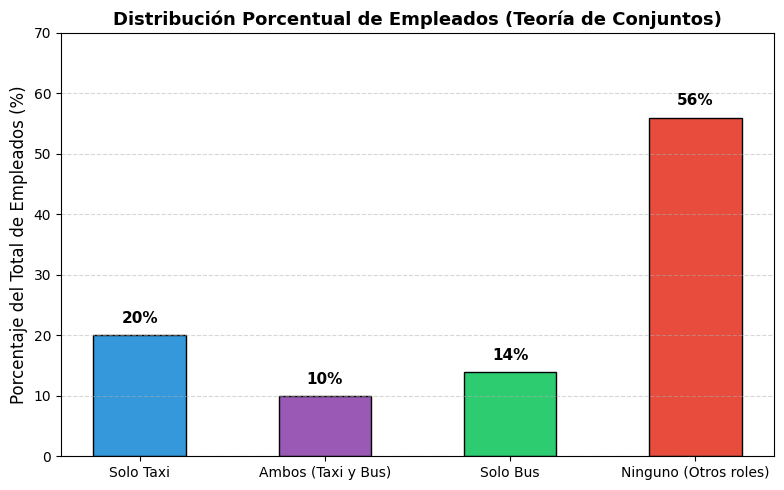

In [15]:

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA CON MATPLOTLIB
# ==========================================
plt.figure(figsize=(8, 5))
colores = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']

# Crear gráfico de barras
barras = plt.bar(df["Clasificación Laboral"], df["Porcentaje (%)"], \
    color=colores, edgecolor='black', width=0.50)

plt.ylabel('Porcentaje del Total de Empleados (%)', fontsize=12)
plt.title('Distribución Porcentual de Empleados (Teoría de Conjuntos)', fontsize=13, weight='bold')
plt.ylim(0, 70)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Poner los valores porcentuales encima de cada barra
for barra in barras:
    alto = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2.0, 
        alto + 1.5, 
        f"{alto:.0f}%", 
        ha='center', 
        va='bottom', 
        fontsize=11,
        weight='bold'
    )

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\grafico_conjuntos.png", dpi=300)
plt.show()



# Conclusión y Respuesta

Al compilar y analizar la distribución total, la porción externa a los conjuntos evaluados abarca exactamente más de la mitad del personal disponible en la empresa de transporte, arrojando el **$56\%$**.

La respuesta correcta es **(c) 56%**.

# Pregunta 7.7 

# 1. Transcripción y Edición del Enunciado

**7.7.** En la gráfica se ilustran los resultados de una encuesta sobre las marcas de carros preferidas por un grupo de personas.

### Distribución de Preferencias (Gráfico Circular)

* **Renault:** $40\%$
* **Chevrolet:** $25\%$
* **Mazda:** $20\%$
* **Otros:** $X\%$

Si del total de encuestados, $200$ prefieren Renault, el número de personas que **no prefieren** Renault, Mazda ni Chevrolet es:

* **(a)** $30$
* **(b)** $75$
* **(c)** $120$
* **(d)** $15$

---

## 2. Resolución Paso a Paso (Análisis Matemático)

Vamos a desglosar el problema de manera lógica y secuencial:

1. **Determinar el porcentaje de la categoría "Otros" ($X\%$):**
Sabemos que la suma de todos los sectores de un diagrama circular debe ser igual al $100\%$. Por lo tanto:

$$40\% + 25\% + 20\% + X\% = 100\%$$


$$85\% + X\% = 100\%$$


$$X\% = 100\% - 85\% = 15\%$$



La categoría "Otros" representa a las personas que **no prefieren** Renault, Mazda ni Chevrolet.
2. **Calcular el total de personas encuestadas:**
El enunciado nos dice que $200$ personas prefieren Renault, lo cual equivale al $40\%$ del total de la población ($N$). Planteamos la regla de tres o ecuación diferencial básica:

$$40\% \text{ de } N = 200$$


$$0.40 \times N = 200$$


$$N = \frac{200}{0.40} = 500 \text{ personas}$$


3. **Calcular el número de personas en la categoría "Otros":**
Buscamos cuántas personas corresponden al $15\%$ determinado en el primer paso (sobre el total de $500$ encuestados):

$$\text{Personas} = 15\% \text{ de } 500$$


$$\text{Personas} = 0.15 \times 500 = 75 \text{ personas}$$



Por lo tanto, el número de personas que no prefieren ninguna de las tres marcas principales es **$75$**. La respuesta correcta es la **(b)**.

---

## 3. Implementación y Validación en Python

Este script realiza el cálculo analítico exacto con **SymPy**, gestiona el balance general de personas con **Pandas** y **NumPy**, y utiliza **Matplotlib** para generar una réplica exacta y estilizada del gráfico circular del examen.


--- Análisis Algebraico con SymPy ---
Porcentaje de 'Otros' (X): 15%
Total de personas encuestadas: 500
Personas que NO prefieren Renault, Mazda ni Chevrolet: 75

--- Distribución Poblacional con Pandas ---
Marca de Carro  Porcentaje (%)  Número de Personas
       Renault            40.0                 200
     Chevrolet            25.0                 125
         Mazda            20.0                 100
         Otros            15.0                  75


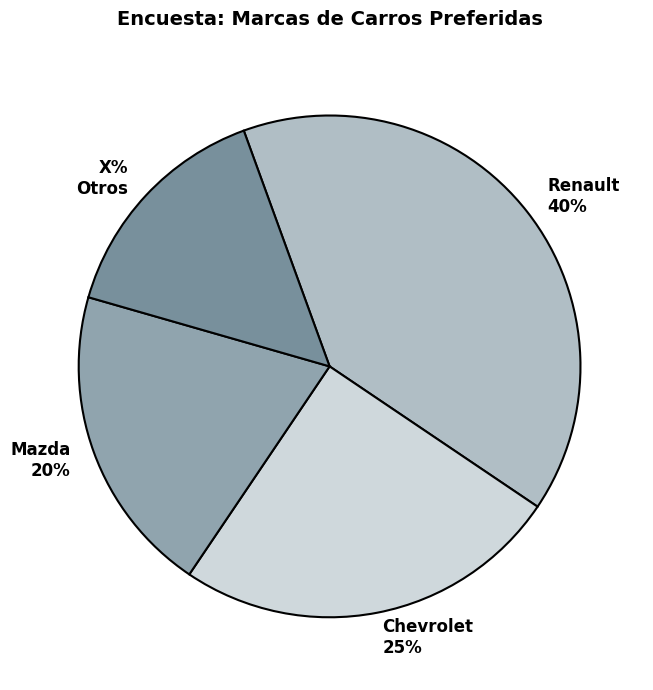

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. CÁLCULO ANALÍTICO CON SYMPY
# ==========================================
print("--- Análisis Algebraico con SymPy ---")

# Definimos variables simbólicas
X = sp.Symbol('X') # Porcentaje de 'Otros'
N = sp.Symbol('N') # Total de encuestados

# Paso 1: Hallar X sabiendo que la suma es 100%
eq_porcentaje = sp.Eq(40 + 25 + 20 + X, 100)
porcentaje_otros = sp.solve(eq_porcentaje, X)[0]

# Paso 2: Hallar el Universo Total (N) partiendo de que 40% de N = 200 personas
eq_total = sp.Eq(sp.Rational(40, 100) * N, 200)
total_encuestados = sp.solve(eq_total, N)[0]

# Paso 3: Calcular las personas en la categoría 'Otros'
personas_otros = sp.Rational(porcentaje_otros, 100) * total_encuestados

print(f"Porcentaje de 'Otros' (X): {porcentaje_otros}%")
print(f"Total de personas encuestadas: {total_encuestados}")
print(f"Personas que NO prefieren Renault, Mazda ni Chevrolet: {personas_otros}")


# ==========================================
# 2. TABLA ESTRUCTURADA CON PANDAS
# ==========================================
print("\n--- Distribución Poblacional con Pandas ---")

# Definimos los porcentajes de cada categoría
marcas = ["Renault", "Chevrolet", "Mazda", "Otros"]
porcentajes = [40.0, 25.0, 20.0, float(porcentaje_otros)]

# Calculamos de manera vectorial el número real de personas con NumPy
total_N = float(total_encuestados)
cantidades = np.array(porcentajes) / 100.0 * total_N

df = pd.DataFrame({
    "Marca de Carro": marcas,
    "Porcentaje (%)": porcentajes,
    "Número de Personas": cantidades.astype(int)
})
print(df.to_string(index=False))


# ==========================================
# 3. SCRIPT DEL DIAGRAMA DE SECTORES (MATPLOTLIB)
# ==========================================
# Configuración del gráfico circular idéntico al enunciado
plt.figure(figsize=(7, 7))

labels = [f'{m}\n{p:.0f}%' if m != "Otros" else f'X%\n{m}' for m, p in zip(marcas, porcentajes)]
colors = ['#b0bec5', '#cfd8dc', '#90a4ae', '#78909c'] # Paleta de grises monocromática tipo examen

# Trazado del gráfico de pastel (Pie chart)
wedges, texts = plt.pie(
    porcentajes, 
    labels=labels,
    colors=colors,
    startangle=110,
    counterclock=False, # Dirección de las manecillas del reloj para semejar el orden visual
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

# Estilizar textos del gráfico
for text in texts:
    text.set_fontsize(12)
    text.set_weight('bold')

plt.title("Encuesta: Marcas de Carros Preferidas", fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()


# Conclusión y Respuesta

La ejecución del script valida algebraicamente que el sector restante no mencionado ($X\%$) equivale al $15\%$ de la torta estadística. Al cruzarlo con el volumen muestral deducido ($500$ sujetos), descubrimos que el grupo que queda por fuera de las marcas líderes está compuesto por **$75$ personas**.

La respuesta correcta es **(b) 75**.

# Pregunta 7.8  

## 1. Transcripción y Edición del Enunciado

**7.8.** En un país los precios de los alimentos en el mes de mayo subieron un $10\%$ y en el mes de junio subieron $5\%$. El aumento en los precios de los alimentos acumulado durante estos 2 meses fue:

* **(a)** $15.5\%$
* **(b)** $16\%$
* **(c)** $13\%$
* **(d)** $14.5\%$




## 2. Resolución Paso a Paso (Análisis Matemático)

Un error muy común al resolver este tipo de problemas es simplemente sumar los porcentajes ($10\% + 5\% = 15\%$), lo cual es incorrecto porque el segundo aumento se aplica sobre el precio que ya había subido en mayo, no sobre el precio inicial. Esto se conoce como **interés compuesto** o **variaciones porcentuales sucesivas**.



Vamos a analizarlo paso a paso asumiendo un precio inicial de base de **100**:

1. **Precio Inicial (Base):** 
$$P_0 = 100$$




2. **Aumento en el mes de mayo ($10\%$):**
El precio sube un $10\%$ de su valor inicial.

$$P_1 = 100 + (10\% \text{ de } 100) = 100 \times (1 + 0.10) = 110$$




3. **Aumento en el mes de junio ($5\%$):**
El precio sube un $5\%$ respecto al nuevo valor ($110$).

$$P_2 = 110 + (5\% \text{ de } 110) = 110 \times (1 + 0.05)$$


$$P_2 = 110 \times 1.05 = 115.5$$




4. **Cálculo del aumento acumulado total:**
Comparamos el precio final del segundo mes con el precio inicial:

$$\text{Aumento Absoluto} = 115.5 - 100 = 15.5$$


$$\text{Porcentaje Acumulado} = \left( \frac{15.5}{100} \right) \times 100 = 15.5\%$$



De forma directa usando factores multiplicativos:


$$\text{Factor Total} = 1.10 \times 1.05 = 1.155$$


Esto representa un valor final de $115.5\%$, es decir, un incremento neto del **$15.5\%$**.

La respuesta correcta es la **(a)**.

---



# 3. Implementación y Validación en Python

Este script utiliza **SymPy** para modelar la fórmula multiplicativa exacta de forma algebraica, **Pandas** y **NumPy** para simular la evolución temporal de los precios de una canasta de alimentos, y **Matplotlib** para graficar de forma didáctica la trayectoria de la inflación acumulada.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# ==========================================
# 1. CÁLCULO ALGEBRAICO CON SYMPY
# ==========================================
print("--- Cálculo de Variaciones Sucesivas con SymPy ---")

# Definimos variables simbólicas para los factores de aumento
f_mayo = sp.Rational(110, 100) # 1 + 10%
f_junio = sp.Rational(105, 100) # 1 + 5%

# Factor acumulado compuesto
factor_acumulado = f_mayo * f_junio
porcentaje_acumulado = (factor_acumulado - 1) * 100

print(f"Factor multiplicativo compuesto: {factor_acumulado}")
print(f"Aumento neto acumulado: {porcentaje_acumulado}%")


# ==========================================
# 2. SIMULACIÓN TEMPORAL CON PANDAS Y NUMPY
# ==========================================
print("\n--- Evolución de Precios en Pandas ---")

# Creamos un índice cronológico y la evolución del valor de un artículo base 100
meses = ["Inicio (Abril)", "Fin de Mayo", "Fin de Junio"]
tasas_mes = [0.0, 0.10, 0.05]

# Calculamos los precios de forma secuencial usando una iteración o productos acumulados de NumPy
precios = [100.0]
for tasa in tasas_mes[1:]:
    precios.append(precios[-1] * (1 + tasa))

df_precios = pd.DataFrame({
    "Mes": meses,
    "Tasa Aplicada": [f"{t*100:.0f}%" for t in tasas_mes],
    "Precio del Alimento ($)": precios,
    "Incremento respecto al Inicio ($)": np.array(precios) - 100.0
})

print(df_precios.to_string(index=False))


# ==========================================
# 3. VISUALIZACIÓN GRÁFICA CON MATPLOTLIB
# ==========================================
# Graficaremos la trayectoria de los precios para ver el efecto compuesto de la inflación
plt.figure(figsize=(8, 5))

plt.plot(df_precios["Mes"], df_precios["Precio del Alimento ($)"], marker='o', color='#e67e22', linewidth=2.5, markersize=8)

# Añadir anotaciones didácticas en cada punto de la gráfica
for i, txt in enumerate(df_precios["Precio del Alimento ($)"]):
    plt.annotate(
        f"${txt:.1f}\n(+{txt-100:.1f}%)", 
        (df_precios["Mes"][i], df_precios["Precio del Alimento ($)"][i]),
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        weight='bold',
        fontsize=10
    )

plt.ylabel('Precio Escalar de Alimentos (Base 100)', fontsize=12)
plt.title('Efecto del Aumento Compuesto de Precios (Mayo - Junio)', fontsize=13, weight='bold')
plt.ylim(95, 125)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\grafico_inflacion_compuesta.png")
plt.show()



# Conclusión y Respuesta

Al ejecutar la simulación, se observa claramente cómo el incremento de junio aporta un poco más de lo que aportaría sobre la base fija original debido al residuo compuesto ($0.5\%$). El acumulado total es **$15.5\%$**.

La respuesta correcta es **(a) 15.5%**.

# Pregunta 7.9  
